<a href="https://colab.research.google.com/github/Veerabomma-Lalithya-Sai/VOIS_AICTE_Oct2025_Veerabomma_Lalithya_Sai/blob/main/Airbnb_hotel_booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px

In [2]:
#Loading the dataset
df=pd.read_excel("/content/1730285881-Airbnb_Open_Data.xlsx")

In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

In [5]:
df.duplicated().value_counts()

,count
False,102058
True,541


In [6]:
df[df['neighbourhood group']=='brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,116.0,4.0,167.0,2019-06-24,1.34,4.0,3.0,47.0,NaN,NaN


In [7]:
# drop duplicates
df.drop_duplicates(inplace=True)

# drop columns with insufficient data
df.drop(['house_rules', 'license'], axis=1, inplace=True, errors='ignore')

# remove dollar signs and convert to float
df['price'] = df['price'].astype(str).str.replace('$', '', regex=True).astype(float)
df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=True).astype(float)

# rename columns
df.rename(columns={'price': 'price_$', 'service fee': 'service_fee_$'}, inplace=True)

# drop all records with missing values
df.dropna(inplace=True)

# change mismatched datatypes
df['price_$'] = df['price_$'].astype(float)
df['service_fee_$'] = df['service_fee_$'].astype(float)
df['id'] = df['id'].astype(str)
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
df['Construction year'] = df['Construction year'].astype(int)

# correct spelling mistake in neighbourhood group
df.loc[df['neighbourhood group'].str.lower() == 'brookln', 'neighbourhood group'] = 'Brooklyn'

# get rid of outliers in availability_365 column
df=df.drop(df[df['availability 365']>500].index)


In [8]:
df.duplicated().value_counts()

,count
False,83389


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83389 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83389 non-null  object        
 1   NAME                            83389 non-null  object        
 2   host id                         83389 non-null  int64         
 3   host_identity_verified          83389 non-null  object        
 4   host name                       83389 non-null  object        
 5   neighbourhood group             83389 non-null  object        
 6   neighbourhood                   83389 non-null  object        
 7   lat                             83389 non-null  float64       
 8   long                            83389 non-null  float64       
 9   country                         83389 non-null  object        
 10  country code                    83389 non-null  object        
 11  instan

In [10]:
df.describe()

,host id,lat,long,instant_bookable,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,8.338900e+04,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389,83389.000000,83389.000000,83389.000000,83389.000000
mean,4.918226e+10,40.727349,-73.948502,0.497704,2012.487810,626.209668,125.243114,7.406109,32.261305,2019-06-08 21:32:53.396971008,1.377352,3.278694,7.032894,141.746369
min,1.236005e+08,40.504560,-74.249840,0.000000,2003.000000,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,2.444702e+10,40.687640,-73.982110,0.000000,2007.000000,340.000000,68.000000,2.000000,3.000000,2018-10-25 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,4.902253e+10,40.721320,-73.953710,0.000000,2012.000000,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,7.384793e+10,40.762600,-73.930800,1.000000,2017.000000,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,266.000000
max,9.876313e+10,40.916970,-73.705220,1.000000,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,426.000000
std,2.853548e+10,0.056326,0.050342,0.499998,5.760526,331.803443,66.364212,28.105563,51.954290,NaN,1.751091,1.283678,29.555458,133.377544


In [11]:
#different types of property types in the dataset
property_types=df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,44161
Private room,37474
Shared room,1646
Hotel room,108


Text(0.5, 1.0, 'Property Types with their count')

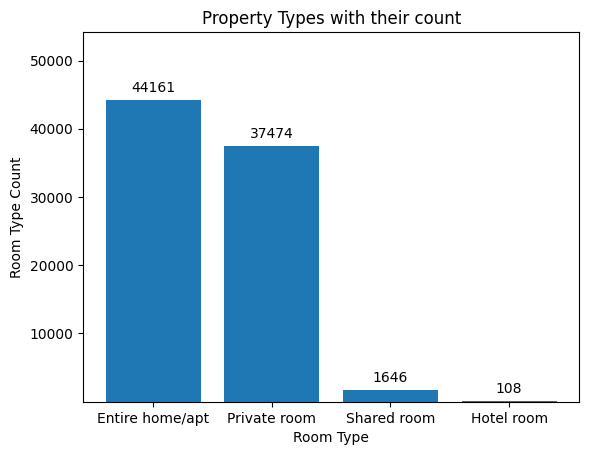

In [12]:
#room type count plotted on bar graph
room_type_bar=plt.bar(property_types.index,property_types.loc[:,"count"]);
plt.bar_label(room_type_bar,labels=property_types.loc[:,"count"],padding=4);
plt.ylim(0.5, property_types["count"].max() + 10000);
plt.xlabel('Room Type')
plt.ylabel('Room Type Count')
plt.title('Property Types with their count')

In [13]:
#neighborhood which has highest number of listings
hood_group=df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,34622
Manhattan,34560
Queens,11124
Bronx,2267
Staten Island,816


Text(0.5, 1.0, 'Neighbourhood Groups vs Number of Listings')

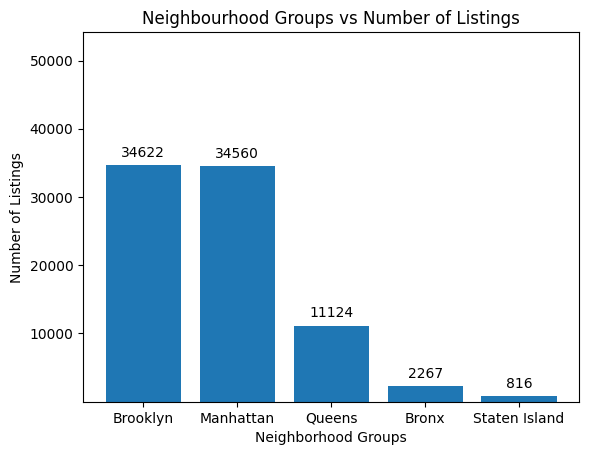

In [14]:
#plot for the highest listing neighborhood group
neighborhood_group_bar=plt.bar(hood_group.index,hood_group.loc[:,"count"]);
plt.bar_label(neighborhood_group_bar,labels=hood_group.loc[:,"count"],padding=4);
plt.ylim(0.5, property_types["count"].max() + 10000);
plt.xlabel('Neighborhood Groups')
plt.ylabel('Number of Listings')
plt.title('Neighbourhood Groups vs Number of Listings')

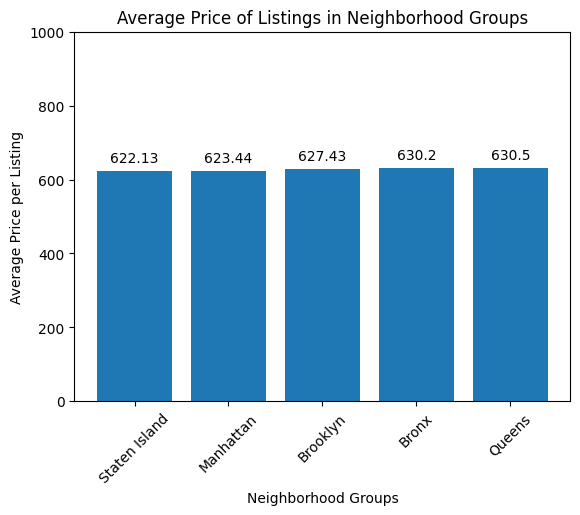

In [15]:
#which neighborhood group has highest average prices for Airbnb listing
avg_price=df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending=True).to_frame()
avg_price_bar=plt.bar(avg_price.index,avg_price.loc[:,"price_$"]);
plt.bar_label(avg_price_bar,labels=round(avg_price.loc[:,"price_$"],2),label_type='edge',padding=4);
plt.ylim([0,1000]);
plt.xlabel('Neighborhood Groups');
plt.ylabel('Average Price per Listing');
plt.xticks(rotation=45);
plt.title('Average Price of Listings in Neighborhood Groups');

Text(0.5, 1.0, 'Relation between Property Price and Construction Year')

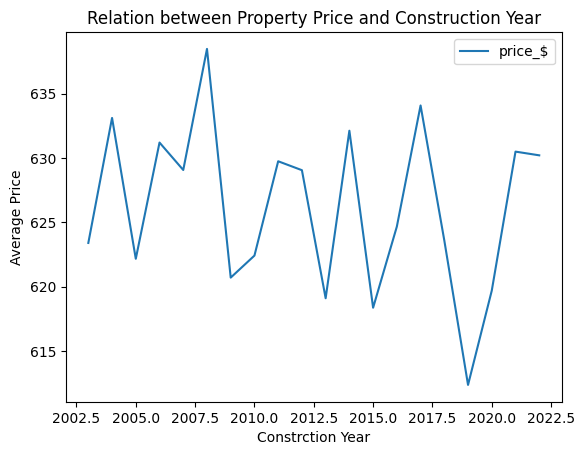

In [16]:
#is there any relation between property price and property construction year?
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot();
plt.xlabel('Constrction Year')
plt.ylabel('Average Price')
plt.title('Relation between Property Price and Construction Year')

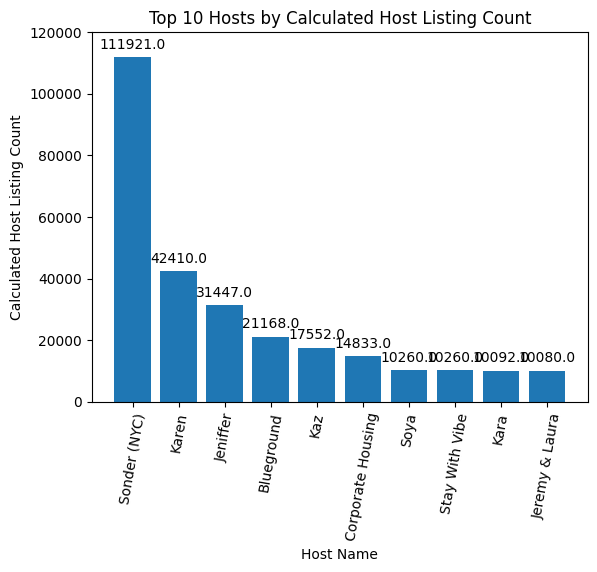

In [17]:
#top 10 hosts by calculated host listing count
hosts=df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending=False).nlargest(10).to_frame()
hosts_bar=plt.bar(hosts.index,hosts.loc[:,"calculated host listings count"]);
plt.bar_label(hosts_bar,labels=hosts.loc[:,"calculated host listings count"],label_type='edge',padding=4);
plt.xlabel('Host Name');
plt.ylabel('Calculated Host Listing Count');
plt.xticks(rotation=80);
plt.ylim([0,120000]);
plt.title('Top 10 Hosts by Calculated Host Listing Count');

In [18]:
from time import asctime
#does hosting with verified indentities always recieve positive reviews
review=df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending=False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.284066
unconfirmed,3.273325


Text(0.5, 1.0, 'Ave Rate of Verification Statistics')

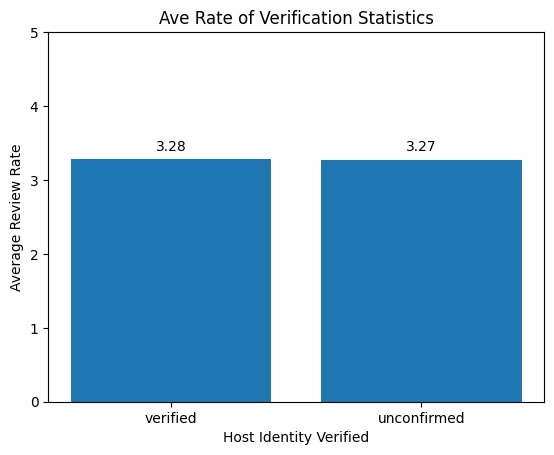

In [19]:
review_bar=plt.bar(review.index,review.loc[:,'review rate number']);
plt.bar_label(review_bar,labels=round(review.loc[:,'review rate number'],2),padding=4);
plt.xlabel('Host Identity Verified');
plt.ylabel('Average Review Rate');
plt.ylim([0,5])
plt.title('Ave Rate of Verification Statistics')

Text(0.5, 1.0, 'Average Review Rate for each Verification Status')

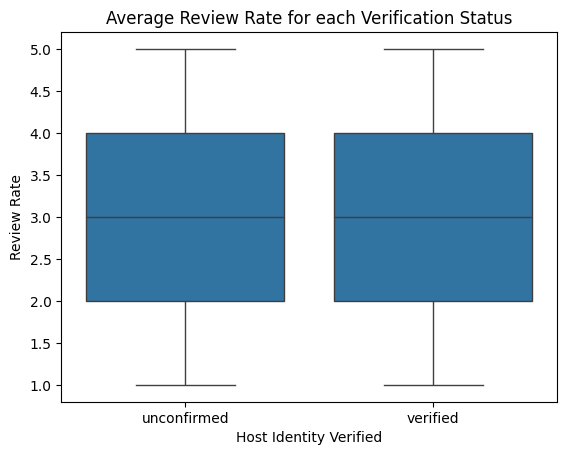

In [20]:
base_color=sns.color_palette()[0]
sns.boxplot(data=df, x='host_identity_verified', y='review rate number', color=base_color);
plt.xlabel('Host Identity Verified');
plt.ylabel('Review Rate');
plt.title('Average Review Rate for each Verification Status')

In [21]:
#correlation between price of a lsiting and service fee
df['price_$'].corr(df['service_fee_$'])

np.float64(0.9999909082976466)

Text(0.5, 1.0, 'Correlation between Price and Service Fee')

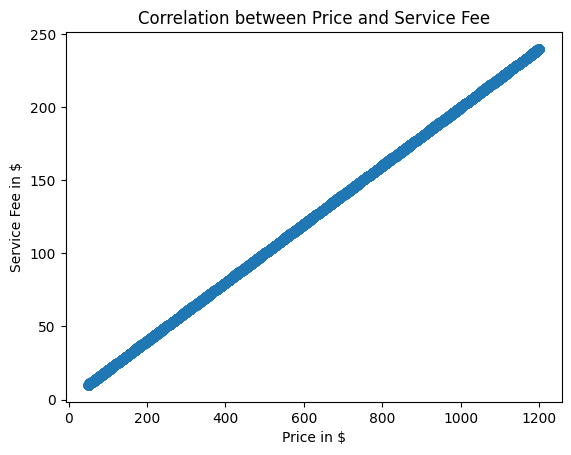

In [22]:
sns.regplot(df,x='price_$',y='service_fee_$');
plt.xlabel('Price in $');
plt.ylabel('Service Fee in $');
plt.title('Correlation between Price and Service Fee')

In [23]:
#what is the avg review rate number
avg_rrn=df.groupby(['neighbourhood','room type'])['review rate number'].mean().to_frame()
avg_rrn

review rate number
neighbourhood room type                          
Allerton      Entire home/apt            3.219512
              Private room               3.357143
Arden Heights Entire home/apt            4.285714
              Private room               2.000000
Arrochar      Entire home/apt            3.192308
...                                           ...
Woodlawn      Shared room                3.000000
Woodrow       Entire home/apt            2.000000
Woodside      Entire home/apt            3.333333
              Private room               3.402332
              Shared room                3.500000

[558 rows x 1 columns]

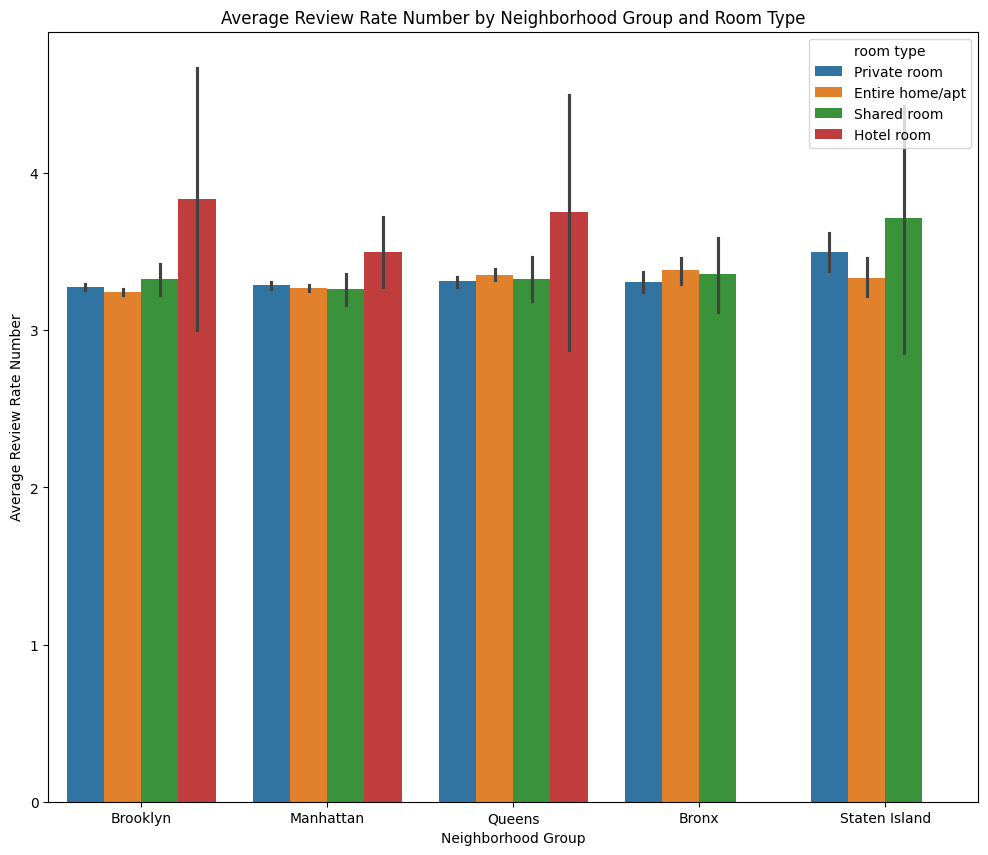

In [26]:
plt.figure(figsize=(12, 10))
sns.barplot(data=df,x='neighbourhood group',y='review rate number',hue='room type');
plt.xlabel('Neighborhood Group');
plt.ylabel('Average Review Rate Number');
plt.title('Average Review Rate Number by Neighborhood Group and Room Type');

Text(0.5, 1.0, 'Relationship between Calculated Host Listing Count and Availability')

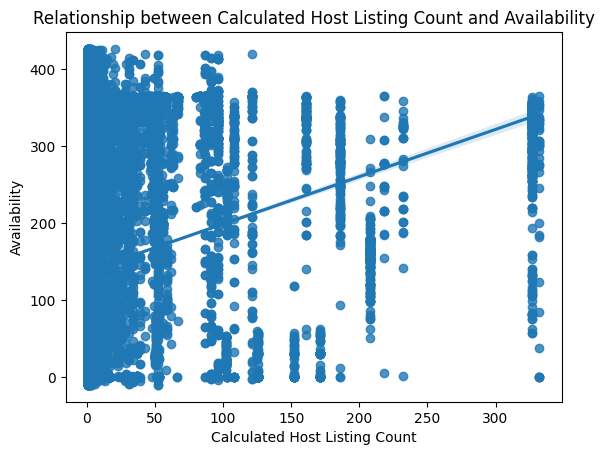

In [28]:
#are the hosts with higher calculated host listing count more likely to maintain higher availability through out the year
sns.regplot(df,x='calculated host listings count', y='availability 365');
plt.xlabel('Calculated Host Listing Count');
plt.ylabel('Availability');
plt.title('Relationship between Calculated Host Listing Count and Availability')

In [29]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.1359971471570339)